In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
import math

In [4]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline  

### Study the data distribution in each attribute, share your findings. (5 points)

In [5]:
#Load the file from local directory which is a special form of read_table
bank_df = pd.read_csv("Bank_Personal_Loan_Modelling.csv")

In [6]:
bank_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [7]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [8]:
print ("***********Each Attribute's Data Type***********\n")
print (" ID=Continuous Numerical\n Age=Continous Numerical\n Experience=Continous Numerical\n Income=Continuous Numerical\n ZIP code=Categorical\n Family=Continous Numerical\n CCAvg=Numerical\n Education=Categorical\n Mortgage=Continous-Numerical\n Personal Loan=Binary-Categorical\n Securities Account=Binary-Categorical\n CD Account=Binary-Categorical\n Online=Binary-Categorical\n CreditCard=Binary-Categorical\n")

***********Each Attribute's Data Type***********

 ID=Continuous Numerical
 Age=Continous Numerical
 Experience=Continous Numerical
 Income=Continuous Numerical
 ZIP code=Categorical
 Family=Continous Numerical
 CCAvg=Numerical
 Education=Categorical
 Mortgage=Continous-Numerical
 Personal Loan=Binary-Categorical
 Securities Account=Binary-Categorical
 CD Account=Binary-Categorical
 Online=Binary-Categorical
 CreditCard=Binary-Categorical



In [9]:
# Correlatiion between different Attributes 
corr_arr = bank_df.corr()
corr_arr

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.008473,-0.008326,-0.017695,0.013432,-0.016797,-0.024675,0.021463,-0.013920,-0.024801,-0.016972,-0.006909,-0.002528,0.017028
Age,-0.008473,1.000000,0.994215,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,-0.008326,0.994215,1.000000,-0.046574,-0.028626,-0.052563,-0.050077,0.013152,-0.010582,-0.007413,-0.001232,0.010353,0.013898,0.008967
Income,-0.017695,-0.055269,-0.046574,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,0.013432,-0.029216,-0.028626,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.016797,-0.046418,-0.052563,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.024675,-0.052012,-0.050077,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.021463,0.041334,0.013152,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.013920,-0.012539,-0.010582,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.024801,-0.007726,-0.007413,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802


In [10]:
# Identify the list of attributes whose correlation is between -0.1 to 0.1 w.r.t target-attribute Personal-loan. Such attributes should not be considered for the calculation 
drop_feature_list = []
corr_pers_loan = corr_arr['Personal Loan']

for i, v in corr_pers_loan.items():
    #print('index:', i, '*value:', v)
    if ((v > -0.1) and (v < 0.1)):
        #print ('Drop Feature =', i)
        drop_feature_list.append (i)

print ("List of attributes which have correlation between -0.1 to 0.1 to the Target-Variable:Personal-Loan = ", drop_feature_list)

# Correlation should be asssessed only for Numeric attributes. Remove the Categorical attributes from this list, except ZipCode 
drop_feature_list.remove('Securities Account')
drop_feature_list.remove('Online')
drop_feature_list.remove('CreditCard')

print ("Final List of Attributes which need to be dropped = ", drop_feature_list)

List of attributes which have correlation between -0.1 to 0.1 to the Target-Variable:Personal-Loan =  ['ID', 'Age', 'Experience', 'ZIP Code', 'Family', 'Securities Account', 'Online', 'CreditCard']
Final List of Attributes which need to be dropped =  ['ID', 'Age', 'Experience', 'ZIP Code', 'Family']


In [11]:
# These attributes should be dropped from the dataframe, as they don't influence the Target-Variable:Personal-Loan
drop_columns = []
drop_columns.append("Personal Loan")
drop_columns += drop_feature_list

# Create a separate dataframe consisting only independent attributes. Also remove the above attributes which have low correlation
X = bank_df.drop(labels = drop_columns, axis = 1)

In [12]:
X.head().T

,0,1,2,3,4
Income,49.0,34.0,11.0,100.0,45.0
CCAvg,1.6,1.5,1.0,2.7,1.0
Education,1.0,1.0,1.0,2.0,2.0
Mortgage,0.0,0.0,0.0,0.0,0.0
Securities Account,1.0,1.0,0.0,0.0,0.0
CD Account,0.0,0.0,0.0,0.0,0.0
Online,0.0,0.0,0.0,0.0,0.0
CreditCard,0.0,0.0,0.0,0.0,1.0


In [13]:
# Check the correlation between attributes, if any is >0.9. If yes, they can be removed. 
corr_arr = X.corr()
corr_arr

,Income,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Income,1.000000,0.645984,-0.187524,0.206806,-0.002616,0.169738,0.014206,-0.002385
CCAvg,0.645984,1.000000,-0.136124,0.109905,0.015086,0.136534,-0.003611,-0.006689
Education,-0.187524,-0.136124,1.000000,-0.033327,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,0.206806,0.109905,-0.033327,1.000000,-0.005411,0.089311,-0.005995,-0.007231
Securities Account,-0.002616,0.015086,-0.010812,-0.005411,1.000000,0.317034,0.012627,-0.015028
CD Account,0.169738,0.136534,0.013934,0.089311,0.317034,1.000000,0.175880,0.278644
Online,0.014206,-0.003611,-0.015004,-0.005995,0.012627,0.175880,1.000000,0.004210
CreditCard,-0.002385,-0.006689,-0.011014,-0.007231,-0.015028,0.278644,0.004210,1.000000


In [14]:
X = X.apply(zscore)  # convert all attributes to Z scale

In [15]:
X.head().T

,0,1,2,3,4
Income,-0.538229,-0.864109,-1.363793,0.569765,-0.625130
CCAvg,-0.193385,-0.250611,-0.536736,0.436091,-0.536736
Education,-1.049078,-1.049078,-1.049078,0.141703,0.141703
Mortgage,-0.555524,-0.555524,-0.555524,-0.555524,-0.555524
Securities Account,2.928915,2.928915,-0.341423,-0.341423,-0.341423
CD Account,-0.253540,-0.253540,-0.253540,-0.253540,-0.253540
Online,-1.216618,-1.216618,-1.216618,-1.216618,-1.216618
CreditCard,-0.645314,-0.645314,-0.645314,-0.645314,1.549632


### Get the target column distribution. Your comments (5 points)

In [16]:
# Capture the class values from the 'Personal Loan' 
y = bank_df['Personal Loan']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Personal Loan, dtype: int64

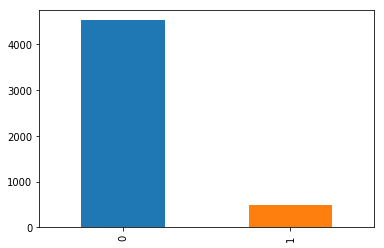

In [17]:
y.value_counts().plot(kind = 'bar')

In [18]:
print ("Number of customers with Personal-Loan among total sample customers (5000): ", y.value_counts()[1])

Number of customers with Personal-Loan among total sample customers (5000):  480


### Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

In [19]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)

### Print the confusion matrix for all the above models (10 points)

#### Logistics Regression Classification Model 

In [20]:
# Logistic Regression Model 
def logisticRegModelPerformanceAnalysis(X_train, X_test, y_train, y_test, model):
        ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > 0.5, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], 0.5, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    # Test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], 0.5, testAccuracy, testRecall, testPrecision, testF1score]
    
    #### Optimize probability threshold and calculate performance numbers
    y_predictProb = model.predict_proba(X_train)
    fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
    optimalF1 = 0
    optimalTh = 0
    for th in thresholds:
        preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
        f1Score = f1_score(y_train, preds)
        if(optimalF1 < f1Score):
            optimalF1 = f1Score
            optimalTh = th
            
    return optimalTh

In [21]:
model = LogisticRegression()
model.fit(X_train, y_train)
optimalTh = logisticRegModelPerformanceAnalysis(X_train, X_test, y_train, y_test, model)
testPreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
testAccuracy = accuracy_score(y_test, testPreds)
testRecall = recall_score(y_test, testPreds)
testPrecision = precision_score(y_test, testPreds)
testF1score = f1_score(y_test, testPreds)

print ("***** Logistic Regression Model Results *****")

ResultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score"])
optimalTestResults = [X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]
# Concatenate Test results to resultsDf
ResultsDf["LR-TestResults"] = optimalTestResults
ResultsDf

C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


***** Logistic Regression Model Results *****


,LR-TestResults
dataSize,1500.000000
accuracy,0.944667
recall,0.695652
precision,0.700730
f1_score,0.698182


##### Confusion Matrix post Logistics Regression Model 

In [22]:
# show Confusion Matrix
metrics.confusion_matrix(y_test, testPreds)

array([[1321,   41],
       [  42,   96]], dtype=int64)

#### KNN Classification Model 

In [23]:
def KNNPerformanceAnalysis(X_train, X_test, y_train, y_test, n_neighbors):
    NNH = KNeighborsClassifier(n_neighbors)
    NNH.fit(X_train, y_train)
    # Test accuracy numbers
    testPreds = NNH.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    return testAccuracy

def KNNIdenfityBestKValue (X_train, X_test, y_train, y_test, max_kvalue):
    opt_accuracy = 0
    opt_kvalue = 0
    opt_mse = 1
    testResults = {}
    for k in range(1, max_kvalue):
        if (k%2):
            model_accuracy = KNNPerformanceAnalysis (X_train, X_test, y_train, y_test, k)
            model_mse = 1 - model_accuracy
            #print ("k = {} Accuracy= {} MSE= {}".format(k, model_accuracy, model_mse))
            testResults[k] = model_mse
            if model_mse < opt_mse:
                opt_mse = model_mse
                opt_kvalue = k
                opt_accuracy = model_accuracy
    print ("\nOptimal-K-Value={} Test-Accuracy={} MSE={} \n".format(opt_kvalue, opt_accuracy, opt_mse))
    return opt_kvalue

In [24]:
# Recommended Kvalue is square-root of N
max_kvalue = int (math.sqrt(y.shape[0]))
print ("Recommended max_kvalue =",max_kvalue)

Recommended max_kvalue = 70


In [25]:
optimal_kvalue = KNNIdenfityBestKValue (X_train, X_test, y_train, y_test, max_kvalue)


Optimal-K-Value=5 Test-Accuracy=0.9693333333333334 MSE=0.03066666666666662 



In [26]:
NNH = KNeighborsClassifier(optimal_kvalue)
NNH.fit(X_train, y_train)

# Test accuracy numbers
testPreds = NNH.predict(X_test)
testAccuracy = accuracy_score(y_test, testPreds)
testRecall = recall_score(y_test, testPreds)
testPrecision = precision_score(y_test, testPreds)
testF1score = f1_score(y_test, testPreds)

print ("***** KNN Classification Model Results *****")
optimalTestResults = [X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]
# Concatenate Test results to resultsDf
ResultsDf["KNN-TestResults"] = optimalTestResults
ResultsDf

***** KNN Classification Model Results *****


,LR-TestResults,KNN-TestResults
dataSize,1500.000000,1500.000000
accuracy,0.944667,0.969333
recall,0.695652,0.717391
precision,0.700730,0.933962
f1_score,0.698182,0.811475


##### Confusion Matrix post KNN Classification Model

In [27]:
# show Confusion Matrix
metrics.confusion_matrix(y_test, testPreds)

array([[1355,    7],
       [  39,   99]], dtype=int64)

### Naïve Bayes Classification Model 

In [28]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

In [29]:
#Train and Fit NaiveBayes Model. The reason for selecting the BernoulliNB NB model is, 4 independent attributes are Binary-Categorical. Also, the accuracy with BernoulliNB is better than GaussianNB.  
model = BernoulliNB()
model.fit(X_train, y_train)

BernoulliNB(alpha=1.0, binarize=0.0, class_prior=None, fit_prior=True)

In [30]:
# make predictions on test
testPreds = model.predict(X_test)

In [31]:
#Show accuracy,  precision and Recall metrics
testAccuracy = accuracy_score(y_test, testPreds)
testRecall = recall_score(y_test, testPreds)
testPrecision = precision_score(y_test, testPreds)
testF1score = f1_score(y_test, testPreds)

optimalTestResults = [X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]
# Concatenate Test results to resultsDf
ResultsDf["NB-TestResults"] = optimalTestResults
ResultsDf

,LR-TestResults,KNN-TestResults,NB-TestResults
dataSize,1500.000000,1500.000000,1500.000000
accuracy,0.944667,0.969333,0.916667
recall,0.695652,0.717391,0.260870
precision,0.700730,0.933962,0.610169
f1_score,0.698182,0.811475,0.365482


##### Confusion Matrix post NaiveBayes Classification Model

In [32]:
# show Confusion Matrix
metrics.confusion_matrix(y_test, testPreds)

array([[1339,   23],
       [ 102,   36]], dtype=int64)

### Give your reasoning on which is the best model in this case and why it performs better? (10 points)

##### Based on the Classification Metrics, KNN Classification Model gives the Best Accuracy Score and F1-Score. 

In [33]:
ResultsDf

,LR-TestResults,KNN-TestResults,NB-TestResults
dataSize,1500.000000,1500.000000,1500.000000
accuracy,0.944667,0.969333,0.916667
recall,0.695652,0.717391,0.260870
precision,0.700730,0.933962,0.610169
f1_score,0.698182,0.811475,0.365482


##### Description of the Results for KNN classification-model
##### * Accuracy (.96): Model can predict at 96% accurary the total number of customers opting+not-opting for personal-loan vs total number of customers 
##### * Recall (0.71): Model can predict at 71% the number of new-customers opting for personal-loan among the total number of customers who will actually opt for personal-loan   
##### * Precision (0.93): Model can predict at 93%, among all the predicted customers opting for personal-loan, how many actually opted for personal loan
##### * Precision indicates the Type-1 Error. Recall indicates the Type-II Error. 

##### Reason for KNN giving best accuracy are listed as below:
##### * We iterated across all the possible K values to ensure optimal K-value is determined
##### * KNN doesn't make any assumption of the data distribution
##### * All the independent attributes were normalized using zscore to ensure there is no bias due to numerical value